# UFTC B-747 — coordinated banked turn with mid-turn engine failure

This notebook is the **maneuver** counterpart of the stationary-trim Phase 1 / Phase 3 / Phase 4 demos. Instead of holding straight-and-level cruise, the aircraft executes a 300 s scenario: a coordinated banked-turn maneuver followed by an extended new-heading hold:

| Window (s) | Phase | What changes |
|------------|-------|--------------|
| 0 – 5      | level cruise | hold V, h, ψ = 0 |
| 5 – 15     | roll-in      | bank φ ramps 0 → +15° (right bank) |
| 15 – 127.95 | steady banked turn | φ = +15°, ψ slews at ≈0.73°/s (consistent with `g·tan(φ)/V`) |
| 127.95 – 137.95 | roll-out | φ ramps +15° → 0 |
| 137.95 – 300 | new-heading hold | φ = 0, ψ = ψ_final |

**Damage**: the **left-outer engine flames out at t = 50 s**, *mid-turn*, so UFTC must keep tracking a slewing reference under asymmetric thrust.

We compare two configurations:
* **Phase 1** — L2 AA-INDI inner + L3 IADP middle + envelope allocator, **no L4 outer, no monitor**.
* **Phase 4** — full UFTC stack: pre-trained L4 D-SAC outer + composite Lyapunov monitor + macro-action dispatcher.

**Plant-agnostic note** — UFTC's reference vector remains `0` throughout. The time-varying maneuver is injected in the *envelope-allocator setpoint* `ref0(t)` that `uftc_state_transform` uses to build the error-form state. UFTC sees a non-trivial drifting error and the cascade compensates online.


## 1. Imports and simulation settings

In [1]:
import warnings
warnings.filterwarnings("ignore")

import math
from pathlib import Path
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import fsolve

from tensoraerospace.aerospacemodel.b747.nonlinear import B747Configuration, trim
from tensoraerospace.aerospacemodel.b747.nonlinear.damage.state import B747DamageState
from tensoraerospace.aerospacemodel.b747.nonlinear.dynamics import b747_ode_6dof
from tensoraerospace.aerospacemodel.b747.nonlinear.damage import (
    DamageProfile, EngineFailureEvent,
)
from tensoraerospace.aerospacemodel.b747.nonlinear.engine import JT9DEngine
from tensoraerospace.aerospacemodel.b747.nonlinear.params import (
    default_parameters, isa_speed_of_sound_ft_s,
)
import importlib
import tensoraerospace.agent.uftc.controller as uftc_controller_module
importlib.reload(uftc_controller_module)
from tensoraerospace.agent.uftc.controller import UFTCConfig, UFTCController
from tensoraerospace.agent.aa_indi.model import AAINDIConfig
from tensoraerospace.agent.iadp.model import IADPConfig
from tensoraerospace.agent.uftc.fdd.detector import FDDConfig
from tensoraerospace.envs.b747_nonlinear import NonlinearB747Env

np.random.seed(0)
import torch
torch.manual_seed(0)

DT = 0.05
TOTAL_TIME = 300.0
DAMAGE_TIME = 50.0
N_EP = int(TOTAL_TIME / DT)         # 6000 steps
DAMAGE_STEP = int(DAMAGE_TIME / DT)

V_REF_FT_S = 674.0
ALT_REF_FT = 20_000.0
PSI_REF_DEG = 0.0

# Coordinated-turn schedule. Sign convention: positive bank phi = right wing
# down (right bank). For a coordinated right turn the heading rate satisfies
#   psi_dot = (g/V) * tan(phi),  positive bank -> positive psi rate.
TURN_BANK_DEG  = 15.0     # peak bank angle (right turn -> positive bank)
TURN_BANK_SIGN = +1.0     # right turn
ROLL_IN_S   = (5.0, 15.0)
STEADY_S    = (15.0, 127.95)
ROLL_OUT_S  = (127.95, 137.95)

print(f"Episode horizon : {TOTAL_TIME:.0f} s ({N_EP} steps @ dt={DT}s)")
print(f"Damage trigger  : t = {DAMAGE_TIME:.0f} s (step {DAMAGE_STEP})")
print(f"Turn schedule   : roll-in {ROLL_IN_S}, steady {STEADY_S}, roll-out {ROLL_OUT_S}")
print(f"Peak bank       : {TURN_BANK_SIGN*TURN_BANK_DEG:+.1f} deg (right bank)")


Episode horizon : 300 s (6000 steps @ dt=0.05s)
Damage trigger  : t = 50 s (step 1000)
Turn schedule   : roll-in (5.0, 15.0), steady (15.0, 127.95), roll-out (127.95, 137.95)
Peak bank       : +15.0 deg (right bank)


## 2. Cruise and one-engine-out trim

Same trim solve as Phase 4: a healthy cruise trim plus a static left-outer-engine-out trim that the envelope allocator blends into during the failure transient. The blend coefficient is `engine_loss_estimate ∈ [0, 1]` driven by the FDD severity output.


In [2]:
trim_result = trim(altitude_ft=ALT_REF_FT, V_ft_s=V_REF_FT_S,
                   config=B747Configuration.NOMINAL)
assert trim_result.converged

delta_e_trim_rad = float(trim_result.elevator_rad)
throttle_trim = float(trim_result.throttle)
theta_ref_deg = math.degrees(trim_result.theta_rad)
healthy_trim_action = np.array([
    delta_e_trim_rad, 0.0, 0.0, throttle_trim,
], dtype=np.float64)

engine_params = default_parameters(B747Configuration.NOMINAL)
engine_model = JT9DEngine(
    n_engines=4,
    sls_thrust_per_engine_lb=engine_params.engine_thrust_max_lb / 4.0,
    idle_frac=engine_params.engine_idle_frac,
    spool_tau_s=engine_params.engine_tau_s,
)

engine_out_params = default_parameters(B747Configuration.NOMINAL)
engine_out_damage_state = B747DamageState.healthy()
engine_out_damage_state.engines_mu[1] = 0.0
engine_out_params.damage_state = engine_out_damage_state
throttle_engine_out_estimate = min(throttle_trim * 4.0 / 3.0, 1.0)

def engine_out_state_from_vars(alpha_rad, beta_rad, theta_rad):
    return np.array([
        V_REF_FT_S * math.cos(alpha_rad) * math.cos(beta_rad),
        V_REF_FT_S * math.sin(beta_rad),
        V_REF_FT_S * math.sin(alpha_rad) * math.cos(beta_rad),
        0.0, 0.0, 0.0,
        0.0, theta_rad, 0.0,
        0.0, 0.0, -ALT_REF_FT,
    ], dtype=np.float64)

def engine_out_trim_residual(z):
    alpha_rad, beta_rad, theta_rad, de_rad, da_rad, dr_rad, throttle_cmd = z
    x = engine_out_state_from_vars(alpha_rad, beta_rad, theta_rad)
    u = np.array([de_rad, da_rad, dr_rad, np.clip(throttle_cmd, 0.0, 1.0)],
                 dtype=np.float64)
    dx = b747_ode_6dof(x, u, 0.0, engine_out_params)
    return np.array([dx[0], dx[1], dx[2], dx[3], dx[4], dx[5], dx[11]], dtype=np.float64)

z0 = np.array([trim_result.alpha_rad, math.radians(-0.44), trim_result.theta_rad,
               delta_e_trim_rad, math.radians(-4.4), math.radians(-2.64),
               throttle_engine_out_estimate], dtype=np.float64)
engine_out_solution, info, ier, msg = fsolve(
    engine_out_trim_residual, z0, full_output=True, xtol=1e-10, maxfev=2_000,
)
engine_out_residual_norm = float(np.linalg.norm(info["fvec"]))
assert ier == 1 and engine_out_residual_norm < 1e-6, msg

(alpha_engine_out_rad, beta_engine_out_rad, theta_engine_out_rad,
 delta_e_engine_out_rad, delta_a_engine_out_rad, delta_r_engine_out_rad,
 throttle_engine_out) = engine_out_solution
throttle_engine_out = float(np.clip(throttle_engine_out, 0.0, 1.0))
engine_out_trim_action = np.array([
    delta_e_engine_out_rad, delta_a_engine_out_rad,
    delta_r_engine_out_rad, throttle_engine_out,
], dtype=np.float64)

print(f"Healthy trim @ FL200, V={V_REF_FT_S:.0f} ft/s:")
print(f"  alpha = theta = {theta_ref_deg:+.3f} deg")
print(f"  delta_e_trim  = {math.degrees(delta_e_trim_rad):+.3f} deg, throttle_trim = {throttle_trim:.4f}")
print(f"Engine-out trim residual norm = {engine_out_residual_norm:.2e}")


Healthy trim @ FL200, V=674 ft/s:
  alpha = theta = +3.603 deg
  delta_e_trim  = -0.722 deg, throttle_trim = 0.5549
Engine-out trim residual norm = 8.27e-15


## 3. Reference schedule — coordinated banked turn

Build a `reference_schedule(t)` returning a target dict `{V, h, theta, psi, phi, beta}`. The bank schedule is a trapezoidal ramp; the heading schedule is the analytic integral of the coordinated-turn rate ψ̇ ≈ g·tan(|φ|) / V over the same window.

Numbers (chosen for a clean-looking maneuver, not maximum aggression):
* Bank: peak +15° (right bank).
* Roll rate: ±1.5 °/s during ramps.
* Steady-turn ψ̇ ≈ g·tan(15°) / V ≈ 32.17·0.268 / 674 ≈ 0.0128 rad/s ≈ **0.732 °/s**.
* Total Δψ ≈ 3.62° (ramp-in) + 0.733·112.95° (steady) + 3.62° (roll-out) ≈ **90.0°**.

θ gets a small +0.3° offset during the turn to compensate for the lift-vector tilt at 15° bank (`L·cos(φ)`-style proxy). β reference stays at 0 in the un-failed phase and blends toward the engine-out β trim post-failure.


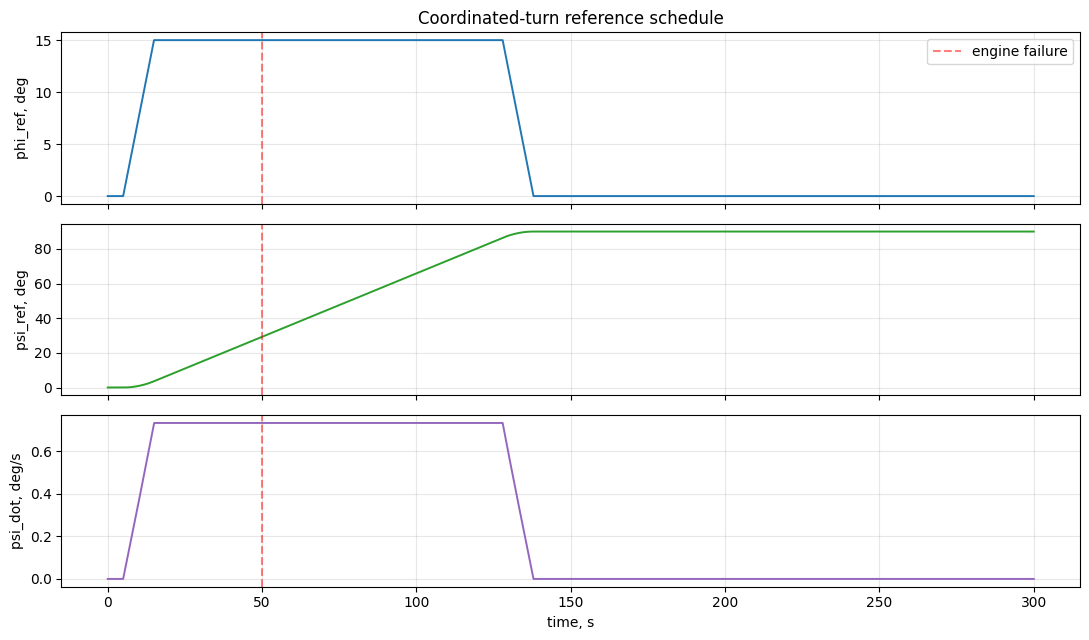

Total heading change Δψ over schedule = +90.01 deg
Steady-turn psi_dot at peak bank      = +0.733 deg/s


In [3]:
G_FT_S2 = 32.17

def _phi_ref_rad(t: float) -> float:
    if t < ROLL_IN_S[0]:
        return 0.0
    if t < ROLL_IN_S[1]:
        frac = (t - ROLL_IN_S[0]) / (ROLL_IN_S[1] - ROLL_IN_S[0])
        return TURN_BANK_SIGN * math.radians(TURN_BANK_DEG) * frac
    if t < STEADY_S[1]:
        return TURN_BANK_SIGN * math.radians(TURN_BANK_DEG)
    if t < ROLL_OUT_S[1]:
        frac = 1.0 - (t - ROLL_OUT_S[0]) / (ROLL_OUT_S[1] - ROLL_OUT_S[0])
        return TURN_BANK_SIGN * math.radians(TURN_BANK_DEG) * frac
    return 0.0

def _psi_dot_coordinated(phi_rad: float, V_ft_s: float) -> float:
    # Coordinated turn: psi_dot = (g/V) * tan(phi).
    # Positive bank (right wing down) -> positive psi rate (right turn).
    return G_FT_S2 * math.tan(phi_rad) / max(V_ft_s, 1.0)

def _phi_dot_ref_rad_s(t: float) -> float:
    if ROLL_IN_S[0] <= t < ROLL_IN_S[1]:
        return TURN_BANK_SIGN * math.radians(TURN_BANK_DEG) / (ROLL_IN_S[1] - ROLL_IN_S[0])
    if ROLL_OUT_S[0] <= t < ROLL_OUT_S[1]:
        return -TURN_BANK_SIGN * math.radians(TURN_BANK_DEG) / (ROLL_OUT_S[1] - ROLL_OUT_S[0])
    return 0.0

# Pre-compute psi_ref(t) by trapezoidal integration of psi_dot(phi_ref(t), V_REF).
_t_grid = np.arange(0.0, TOTAL_TIME + DT, DT)
_phi_grid = np.array([_phi_ref_rad(float(t)) for t in _t_grid])
_psi_dot_grid = np.array([_psi_dot_coordinated(float(p), V_REF_FT_S) for p in _phi_grid])
_psi_grid = np.zeros_like(_t_grid)
for i in range(1, len(_t_grid)):
    _psi_grid[i] = _psi_grid[i-1] + 0.5 * DT * (_psi_dot_grid[i-1] + _psi_dot_grid[i])
PSI_FINAL_RAD = float(_psi_grid[int(ROLL_OUT_S[1] / DT)])

def _psi_ref_rad(t: float) -> float:
    if t <= 0.0:
        return 0.0
    if t >= ROLL_OUT_S[1]:
        return PSI_FINAL_RAD
    return float(np.interp(t, _t_grid, _psi_grid))

def _theta_offset_rad(t: float) -> float:
    # Small pitch/lift compensation that follows bank demand continuously.
    # This avoids a pitch-reference step during the healthy turn.
    peak_phi = max(math.radians(abs(TURN_BANK_DEG)), 1e-9)
    bank_fraction = abs(_phi_ref_rad(t)) / peak_phi
    return math.radians(0.3) * bank_fraction ** 2

def reference_schedule(t: float, beta_target_rad: float = 0.0) -> dict:
    phi_ref = _phi_ref_rad(t)
    return {
        "V": V_REF_FT_S,
        "h": ALT_REF_FT,
        "theta": float(trim_result.theta_rad) + _theta_offset_rad(t),
        "psi": _psi_ref_rad(t),
        "phi": phi_ref,
        "beta": beta_target_rad,
        "phi_dot": _phi_dot_ref_rad_s(t),
        "psi_dot": _psi_dot_coordinated(phi_ref, V_REF_FT_S),
    }

# Visualise the reference
phi_ref_deg = np.degrees(_phi_grid)
psi_ref_deg = np.degrees(_psi_grid)
psi_dot_deg_s = np.degrees(_psi_dot_grid)

fig, axes = plt.subplots(3, 1, figsize=(11, 6.5), sharex=True)
axes[0].plot(_t_grid, phi_ref_deg, color='tab:blue', lw=1.4)
axes[0].axvline(DAMAGE_TIME, color='red', ls='--', alpha=0.5, label='engine failure')
axes[0].set_ylabel('phi_ref, deg'); axes[0].grid(True, alpha=0.3); axes[0].legend()
axes[1].plot(_t_grid, psi_ref_deg, color='tab:green', lw=1.4)
axes[1].axvline(DAMAGE_TIME, color='red', ls='--', alpha=0.5)
axes[1].set_ylabel('psi_ref, deg'); axes[1].grid(True, alpha=0.3)
axes[2].plot(_t_grid, psi_dot_deg_s, color='tab:purple', lw=1.4)
axes[2].axvline(DAMAGE_TIME, color='red', ls='--', alpha=0.5)
axes[2].set_xlabel('time, s'); axes[2].set_ylabel('psi_dot, deg/s'); axes[2].grid(True, alpha=0.3)
axes[0].set_title('Coordinated-turn reference schedule')
plt.tight_layout(); plt.show()
print(f'Total heading change Δψ over schedule = {math.degrees(PSI_FINAL_RAD):+.2f} deg')
print(f'Steady-turn psi_dot at peak bank      = '
      f'{math.degrees(_psi_dot_coordinated(TURN_BANK_SIGN*math.radians(TURN_BANK_DEG), V_REF_FT_S)):+.3f} deg/s')


## 4. Damage profile — engine failure at t = 50 s

The stock `LEFT_OUTER_ENGINE_FAILURE` preset triggers the failure at t = 10 s. We construct a local `DamageProfile` with the same `EngineFailureEvent` parameters but `trigger_time=DAMAGE_TIME=50 s`.


In [4]:
TURN_ENGINE_FAILURE = DamageProfile(
    events=[
        EngineFailureEvent(
            trigger_time=DAMAGE_TIME,
            engine_id=1,
            thrust_fraction=0.0,
            label='left_outer_engine_flameout_mid_turn',
        ),
    ],
)
print(f'Damage profile: {TURN_ENGINE_FAILURE.events[0]}')


Damage profile: EngineFailureEvent(trigger_time=50.0, engine_id=1, thrust_fraction=0.0, label='left_outer_engine_flameout_mid_turn')


## 5. UFTC controller and helpers

The UFTC state remains `[eV, eh, e_theta, e_psi, e_phi, e_beta, p, q, r]` — exactly as in the Phase 4 demo. The only change: `uftc_state_transform` now takes a **time-varying** setpoint `ref_t` instead of a frozen `ref0`. Everything downstream stays the same.


In [5]:
UFTC_RESIDUAL_SCALE = np.array([
    0.0,
    math.radians(0.05),
    math.radians(0.05),
    0.0,
], dtype=np.float64)

UFTC_STATE_SCALE = np.array([
    25.0, 250.0,
    math.radians(3.0), math.radians(8.0),
    math.radians(8.0), math.radians(2.0),
    1.0, 1.0, 1.0,
], dtype=np.float64)
N_UFTC_STATE = int(UFTC_STATE_SCALE.size)
UFTC_OMEGA_INDICES = [6, 7, 8]
UFTC_REFERENCE = np.zeros(N_UFTC_STATE, dtype=np.float64)

UFTC_F_INIT = np.eye(N_UFTC_STATE, dtype=np.float64) * 0.99
UFTC_F_INIT[2, 7] = DT / UFTC_STATE_SCALE[2]
UFTC_F_INIT[3, 8] = DT / UFTC_STATE_SCALE[3]
UFTC_F_INIT[4, 6] = DT / UFTC_STATE_SCALE[4]

UFTC_G_INIT = np.zeros((N_UFTC_STATE, 4), dtype=np.float64)
UFTC_G_INIT[0] = [0.0, 0.0, 0.0, 0.08]
UFTC_G_INIT[1] = [-0.02, 0.0, 0.0, 0.03]
UFTC_G_INIT[6] = [0.00, 0.30, 0.00, 0.00]
UFTC_G_INIT[7] = [0.40, 0.00, 0.00, 0.10]
UFTC_G_INIT[8] = [0.00, 0.05, 0.30, 0.00]
UFTC_G_INNER = UFTC_G_INIT[UFTC_OMEGA_INDICES].copy()

L4_ACTION_SCALE = 0.05
L4_TRIM_FREE_INDICES = {'V_idx': 0, 'gamma_idx': 1, 'alpha_idx': 2, 'q_idx': 7}

# Phase 4 monitor calibration — relaxed d=(80,)*5 to keep the alarm meaningful
# during a long maneuver that already drives V_INDI/V_FDD higher.
MONITOR_CFG = dict(
    enable_monitor=True,
    monitor_c_weights=(0.0, 0.4, 0.0, 0.3, 0.3),
    monitor_d_disturbance=(80.0,) * 5,
    monitor_alarm_warn_frac=0.4,
    monitor_alarm_critical_frac=0.7,
    monitor_cooldown_steps=20,
)

def make_env(damage_profile=None, n_steps=N_EP + 5):
    return NonlinearB747Env(
        trim_at=(ALT_REF_FT, V_REF_FT_S),
        number_time_steps=n_steps,
        dt=DT, integrator='rk4', action_space='virtual',
        config=B747Configuration.NOMINAL,
        damage_profile=damage_profile,
    )

def make_controller(*, enable_l4_outer=True, enable_trim_free=True,
                    enable_monitor=True):
    cfg_kwargs = dict(
        dt=DT,
        fdd_warmup_steps=0,
        omega_indices=UFTC_OMEGA_INDICES,
        middle_lookahead_dt=0.3,
        trust_radius_nominal=0.03,
        trust_radius_fault=0.15,
        fdd_cfg=FDDConfig(process_noise=1e-4, measurement_noise=1e-3,
                          adapt_Q=False, adapt_R=False, drift=6.0, h_alarm=15.0),
        inner_cfg=AAINDIConfig(dt=DT, ref_wn=3.0, ref_zeta=0.9,
                               u_magnitude_limit=1.0, u_rate_limit=5.0,
                               G_init=UFTC_G_INNER, ref_error_kp=2.0,
                               ref_error_ki=0.05, seed=0),
        middle_cfg=IADPConfig(dt=DT,
                              Q=np.diag([20., 40., 20., 20., 20., 0.5, 2., 2., 2.]),
                              R=np.diag([8., 8., 8., 20.]),
                              gamma=0.85, gamma_rls=0.995,
                              u_magnitude_limit=1.0, u_rate_limit=4.0,
                              policy_eval_every=80, policy_eval_blend=0.15),
        enable_l4_outer=bool(enable_l4_outer),
        l4_action_scale=L4_ACTION_SCALE,
        l4_eval_mode=True,
        l4_seed=0,
        l4_trim_free=(L4_TRIM_FREE_INDICES if enable_trim_free else None),
    )
    if enable_monitor:
        cfg_kwargs.update(MONITOR_CFG)
    return UFTCController(
        n_state=N_UFTC_STATE, n_control=4,
        nominal_F=UFTC_F_INIT, nominal_G=UFTC_G_INIT,
        config=UFTCConfig(**cfg_kwargs),
    )


In [6]:
STATE_FEEDBACK_GAINS = {
    'de_h': 2.5e-3,
    'de_theta': 1.8,
    'de_q': 1.0,
    'throttle_v': -1.2e-1,
    'throttle_h': -2.0e-4,
    'da_phi': -2.5,
    'da_p': -1.5,
    'da_phi_dot': 2.25,
    'dr_r': 3.0,
    'dr_psi': 1.5,
    'dr_beta': -0.5,
    'dr_psi_dot': -3.0,
}

def wrap_deg(angle_deg):
    return (float(angle_deg) + 180.0) % 360.0 - 180.0

def wrap_rad(angle_rad):
    return (float(angle_rad) + math.pi) % (2.0 * math.pi) - math.pi

def true_airspeed_ft_s(obs):
    obs = np.asarray(obs, dtype=np.float64).reshape(-1)
    return float(np.linalg.norm(obs[:3]))

def altitude_ft(obs):
    return float(-np.asarray(obs, dtype=np.float64).reshape(-1)[11])

def body_sideslip_rad(obs):
    obs = np.asarray(obs, dtype=np.float64).reshape(-1)
    v = max(true_airspeed_ft_s(obs), 1.0)
    return float(math.asin(np.clip(obs[1] / v, -1.0, 1.0)))

def engine_mu_from_info(info):
    damage_state = info.get('damage_state', {}) if isinstance(info, dict) else {}
    em = damage_state.get('engines_mu', {}) if isinstance(damage_state, dict) else {}
    return {eid: float(em.get(eid, em.get(str(eid), 1.0))) for eid in (1,2,3,4)}

def engine_loss_from_info(info, fallback=0.0):
    em = engine_mu_from_info(info)
    if not em:
        return float(fallback)
    return float(np.clip(1.0 - em.get(1, 1.0), 0.0, 1.0))

def per_engine_thrust_lb(obs, throttle, em):
    h = altitude_ft(obs)
    mach = true_airspeed_ft_s(obs) / isa_speed_of_sound_ft_s(h)
    cluster = engine_model.installed_thrust(mach=mach, altitude_ft=h, throttle=throttle)
    per = cluster / 4.0
    return np.array([per * float(em.get(eid, 1.0)) for eid in (1,2,3,4)], dtype=np.float64)

def trim_action_for_loss(loss):
    f = float(np.clip(loss, 0.0, 1.0))
    return (1.0 - f) * healthy_trim_action + f * engine_out_trim_action

def clip_physical_action(action):
    a = np.asarray(action, dtype=np.float64).reshape(4)
    return np.array([
        np.clip(a[0], -math.radians(25.0), math.radians(25.0)),
        np.clip(a[1], -math.radians(20.0), math.radians(20.0)),
        np.clip(a[2], -math.radians(25.0), math.radians(25.0)),
        np.clip(a[3], 0.0, 1.0),
    ], dtype=np.float64)

def uftc_state_transform_dyn(obs, ref_t, engine_loss_estimate):
    obs = np.asarray(obs, dtype=np.float64).reshape(-1)
    loss = float(np.clip(engine_loss_estimate, 0.0, 1.0))
    beta_target = (1.0 - loss) * ref_t['beta'] + loss * beta_engine_out_rad
    raw = np.array([
        true_airspeed_ft_s(obs) - ref_t['V'],
        altitude_ft(obs) - ref_t['h'],
        wrap_rad(obs[7] - ref_t['theta']),
        wrap_rad(obs[8] - ref_t['psi']),
        wrap_rad(obs[6] - ref_t['phi']),
        body_sideslip_rad(obs) - beta_target,
        obs[3], obs[4], obs[5],
    ], dtype=np.float64)
    return raw / UFTC_STATE_SCALE

def state_feedback_action_dyn(x_uftc, ref_t, engine_loss_estimate):
    x = np.asarray(x_uftc, dtype=np.float64).reshape(N_UFTC_STATE)
    v_err, h_err = x[0]*UFTC_STATE_SCALE[0], x[1]*UFTC_STATE_SCALE[1]
    theta_err = x[2]*UFTC_STATE_SCALE[2]
    psi_err = x[3]*UFTC_STATE_SCALE[3]
    phi_err = x[4]*UFTC_STATE_SCALE[4]
    beta_err = x[5]*UFTC_STATE_SCALE[5]
    p, q, r = x[6], x[7], x[8]
    phi_dot_ref = float(ref_t.get('phi_dot', 0.0))
    psi_dot_ref = float(ref_t.get('psi_dot', 0.0))
    action = trim_action_for_loss(engine_loss_estimate)
    action[0] += (STATE_FEEDBACK_GAINS['de_h']*h_err
                  + STATE_FEEDBACK_GAINS['de_theta']*theta_err
                  + STATE_FEEDBACK_GAINS['de_q']*q)
    action[1] += (STATE_FEEDBACK_GAINS['da_phi']*phi_err
                  + STATE_FEEDBACK_GAINS['da_p']*p
                  + STATE_FEEDBACK_GAINS['da_phi_dot']*phi_dot_ref)
    action[2] += (STATE_FEEDBACK_GAINS['dr_r']*r
                  + STATE_FEEDBACK_GAINS['dr_psi']*psi_err
                  + STATE_FEEDBACK_GAINS['dr_beta']*beta_err
                  + STATE_FEEDBACK_GAINS['dr_psi_dot']*psi_dot_ref)
    action[3] += STATE_FEEDBACK_GAINS['throttle_v']*v_err + STATE_FEEDBACK_GAINS['throttle_h']*h_err
    return clip_physical_action(action)

def compose_action(state_feedback, uftc_action_norm):
    residual = UFTC_RESIDUAL_SCALE * np.clip(
        np.asarray(uftc_action_norm, dtype=np.float64).reshape(4), -1.0, 1.0)
    return clip_physical_action(np.asarray(state_feedback, dtype=np.float64).reshape(4) + residual)


## 6. Pre-trained L4 D-SAC weights (optional)

Load `actor.pt` / `critic*.pt` / `target*.pt` from `artifacts/dsac/b747_engine_out_v1/` if available, otherwise fall back to a random-init actor with a printed note.

**Caveat**: those weights were trained on the stationary-trim engine-out task, *not* on a banked turn. The actor will give degraded performance during the maneuver — that's an honest result and a curriculum-extension argument, not a stack failure.


In [7]:
from tensoraerospace.agent.uftc.l4.dsac import DSACOuter

_REL = Path('artifacts/dsac/b747_engine_out_v1')
_candidates = [_REL]
_cwd = Path.cwd().resolve()
for parent in [_cwd, *_cwd.parents]:
    cand = parent / _REL
    if cand not in _candidates:
        _candidates.append(cand)
weights_path = None
for cand in _candidates:
    if cand.exists() and (cand / 'actor.pt').exists():
        weights_path = cand
        break
PRETRAINED_AVAILABLE = weights_path is not None

def _load_pretrained_into(ctl_target):
    pretrained = DSACOuter.from_pretrained(weights_path)
    ctl_target.l4.actor.load_state_dict(pretrained.actor.state_dict())
    ctl_target.l4.critic1.load_state_dict(pretrained.critic1.state_dict())
    ctl_target.l4.critic2.load_state_dict(pretrained.critic2.state_dict())
    ctl_target.l4.target1.load_state_dict(pretrained.target1.state_dict())
    ctl_target.l4.target2.load_state_dict(pretrained.target2.state_dict())

if PRETRAINED_AVAILABLE:
    print(f'Pre-trained L4 weights found at {weights_path}')
else:
    print('No pre-trained L4 weights found - using random-init actor (eval_mode demonstration)')


Pre-trained L4 weights found at /home/mr8bit/Projects/TensorAeroSpace/artifacts/dsac/b747_engine_out_v1


## 7. Closed-loop rollout helper

`run_uftc_episode_turn(damage_profile, ctl)` follows the Phase 4 rollout pattern but feeds the time-varying reference into `uftc_state_transform_dyn` and `state_feedback_action_dyn`. UFTC's `reference` argument stays at zero; the time-varying reference enters through the envelope-allocator setpoint.


In [8]:
def run_uftc_episode_turn(damage_profile, *, ctl):
    env = make_env(damage_profile=damage_profile)
    obs, _ = env.reset()
    ctl.reset()
    engine_loss_estimate = 0.0

    log_keys = [
        'V', 'h', 'theta', 'psi', 'phi', 'beta',
        'V_actual', 'h_actual', 'theta_actual', 'psi_actual', 'phi_actual', 'beta_actual',
        'x_e', 'y_e',
        'V_ref', 'h_ref', 'theta_ref', 'psi_ref', 'phi_ref', 'beta_ref',
        'p', 'q', 'r',
        'de', 'da', 'dr', 'throttle',
        'engine_loss_estimate',
        'T1','T2','T3','T4','T_total',
        'severity', 'fault_present', 'rls_gamma', 'innovation_norm',
        'l4_beta', 'l4_replay_size', 'l4_r_eff_norm',
        'V_total', 'V_hj', 'V_indi', 'V_iadp', 'V_dsac', 'V_fdd',
        'alarm_level', 'mu_uub_pred',
    ]
    logs = {k: np.zeros(N_EP, dtype=np.float64) for k in log_keys}
    t_axis = np.arange(N_EP, dtype=np.float64) * DT
    t_log_axis = np.zeros(N_EP, dtype=np.float64)
    macro_events = []
    alarm_trans = []
    prev_alarm = 'OK'

    for k in range(N_EP - 2):
        t_now = t_axis[k]
        ref_t = reference_schedule(float(t_now))
        x_uftc = uftc_state_transform_dyn(obs, ref_t, engine_loss_estimate)
        feedback_action = state_feedback_action_dyn(x_uftc, ref_t, engine_loss_estimate)
        u_norm = ctl.predict(x_uftc, UFTC_REFERENCE, time_step=k)
        action = compose_action(feedback_action, u_norm)

        obs, _, _, trunc, info = env.step(action)
        engine_loss_estimate = engine_loss_from_info(info, fallback=engine_loss_estimate)
        t_log = float(t_axis[k+1] if k+1 < N_EP else t_now + DT)
        ref_log = reference_schedule(t_log)
        next_x_uftc = uftc_state_transform_dyn(obs, ref_log, engine_loss_estimate)
        ctl.learn(next_x_uftc, UFTC_REFERENCE, time_step=k)

        diag = ctl.diagnostics()
        l4_diag = diag.get('l4', {})
        mon_out = getattr(ctl, '_monitor_out', None)
        if mon_out is not None:
            v_hj = float(mon_out.components.V_hj)
            v_indi = float(mon_out.components.V_indi)
            v_iadp = float(mon_out.components.V_iadp)
            v_dsac = float(mon_out.components.V_dsac)
            v_fdd = float(mon_out.components.V_fdd)
            v_total = float(mon_out.V_total)
            mu_pred = float(mon_out.mu_uub_pred)
            cur_alarm = str(mon_out.alarm)
            for ma in mon_out.interventions:
                macro_events.append((k, t_axis[k], str(ma.kind), dict(ma.payload)))
            if cur_alarm != prev_alarm:
                alarm_trans.append((k, t_axis[k], prev_alarm, cur_alarm))
                prev_alarm = cur_alarm
        else:
            v_hj = v_indi = v_iadp = v_dsac = v_fdd = 0.0
            v_total = 0.0; mu_pred = 0.0; cur_alarm = 'OK'
        alarm_int = {'OK': 0, 'WARN': 1, 'CRITICAL': 2}.get(cur_alarm, 0)

        v_actual = true_airspeed_ft_s(obs)
        h_actual = altitude_ft(obs)
        theta_actual = math.degrees(obs[7])
        psi_actual = wrap_deg(math.degrees(obs[8]))
        phi_actual = math.degrees(obs[6])
        beta_actual = math.degrees(body_sideslip_rad(obs))
        x_e_actual = float(obs[9])
        y_e_actual = float(obs[10])
        beta_ref_effective_rad = ((1.0 - engine_loss_estimate) * ref_log['beta']
                                  + engine_loss_estimate * beta_engine_out_rad)
        beta_ref_effective_deg = math.degrees(beta_ref_effective_rad)

        # Log the post-step state at t + dt and compare it with the reference at the same time.
        t_log_axis[k] = t_log
        logs['V'][k] = v_actual - ref_log['V']
        logs['h'][k] = h_actual - ref_log['h']
        logs['theta'][k] = math.degrees(wrap_rad(obs[7] - ref_log['theta']))
        logs['psi'][k] = math.degrees(wrap_rad(obs[8] - ref_log['psi']))
        logs['phi'][k] = math.degrees(wrap_rad(obs[6] - ref_log['phi']))
        logs['beta'][k] = beta_actual - beta_ref_effective_deg

        logs['V_actual'][k] = v_actual
        logs['h_actual'][k] = h_actual
        logs['theta_actual'][k] = theta_actual
        logs['psi_actual'][k] = psi_actual
        logs['phi_actual'][k] = phi_actual
        logs['beta_actual'][k] = beta_actual
        logs['x_e'][k] = x_e_actual
        logs['y_e'][k] = y_e_actual
        logs['V_ref'][k] = ref_log['V']
        logs['h_ref'][k] = ref_log['h']
        logs['theta_ref'][k] = math.degrees(ref_log['theta'])
        logs['psi_ref'][k] = math.degrees(ref_log['psi'])
        logs['phi_ref'][k] = math.degrees(ref_log['phi'])
        logs['beta_ref'][k] = beta_ref_effective_deg
        logs['p'][k] = math.degrees(obs[3])
        logs['q'][k] = math.degrees(obs[4])
        logs['r'][k] = math.degrees(obs[5])
        logs['de'][k] = math.degrees(action[0])
        logs['da'][k] = math.degrees(action[1])
        logs['dr'][k] = math.degrees(action[2])
        logs['throttle'][k] = float(action[3])
        logs['engine_loss_estimate'][k] = engine_loss_estimate
        thr = per_engine_thrust_lb(obs, float(action[3]), engine_mu_from_info(info))
        logs['T1'][k], logs['T2'][k], logs['T3'][k], logs['T4'][k] = thr
        logs['T_total'][k] = float(np.sum(thr))
        logs['severity'][k] = float(diag['severity'])
        logs['fault_present'][k] = float(diag['fault_present'])
        logs['rls_gamma'][k] = float(diag['rls_gamma'])
        logs['innovation_norm'][k] = float(diag['innovation_norm'])
        logs['l4_beta'][k] = float(l4_diag.get('beta_t', 0.0))
        logs['l4_replay_size'][k] = float(l4_diag.get('replay_size', 0))
        last_r_eff = getattr(ctl, '_last_r_eff', None)
        if last_r_eff is not None:
            logs['l4_r_eff_norm'][k] = float(np.linalg.norm(last_r_eff))
        logs['V_total'][k] = v_total
        logs['V_hj'][k] = v_hj
        logs['V_indi'][k] = v_indi
        logs['V_iadp'][k] = v_iadp
        logs['V_dsac'][k] = v_dsac
        logs['V_fdd'][k] = v_fdd
        logs['alarm_level'][k] = float(alarm_int)
        logs['mu_uub_pred'][k] = mu_pred
        if trunc:
            break

    n = k + 1
    out = {key: vals[:n] for key, vals in logs.items()}
    out['t'] = t_log_axis[:n]
    out['macro_events'] = macro_events
    out['alarm_transitions'] = alarm_trans
    return out


In [9]:
def run_open_loop_episode_turn(damage_profile):
    """TRUE open-loop rollout: aircraft holds the healthy cruise trim
    throughout. NO state feedback, NO turn-schedule pilot input, NO
    UFTC adaptation, NO engine-loss compensation. When the engine fails
    mid-flight, the aircraft simply diverges — yaw/roll moments from the
    asymmetric thrust propagate freely with no controller reaction.

    The reference schedule is still recorded in the log so the 3D viewer
    chart overlay shows what the aircraft *should* be doing vs. what it
    actually does (i.e., nothing).
    """
    env = make_env(damage_profile=damage_profile)
    obs, _ = env.reset()

    # Static healthy-trim action — no maneuver, no feedback.
    nominal_action = np.array([
        float(trim_result.elevator_rad),
        0.0,
        0.0,
        float(trim_result.throttle),
    ], dtype=np.float64)

    log_keys = [
        'V', 'h', 'theta', 'psi', 'phi', 'beta',
        'V_actual', 'h_actual', 'theta_actual', 'psi_actual', 'phi_actual', 'beta_actual',
        'x_e', 'y_e',
        'V_ref', 'h_ref', 'theta_ref', 'psi_ref', 'phi_ref', 'beta_ref',
        'p', 'q', 'r',
        'de', 'da', 'dr', 'throttle',
        'engine_loss_estimate',
        'T1', 'T2', 'T3', 'T4', 'T_total',
        'severity', 'fault_present', 'rls_gamma', 'innovation_norm',
        'l4_beta', 'l4_replay_size', 'l4_r_eff_norm',
        'V_total', 'V_hj', 'V_indi', 'V_iadp', 'V_dsac', 'V_fdd',
        'alarm_level', 'mu_uub_pred',
    ]
    logs = {k: np.zeros(N_EP, dtype=np.float64) for k in log_keys}
    t_axis = np.arange(N_EP, dtype=np.float64) * DT
    t_log_axis = np.zeros(N_EP, dtype=np.float64)

    for k in range(N_EP - 2):
        t_now = t_axis[k]
        obs, _, _, trunc, info = env.step(nominal_action)
        t_log = float(t_axis[k+1] if k+1 < N_EP else t_now + DT)

        v_actual = true_airspeed_ft_s(obs)
        h_actual = altitude_ft(obs)
        theta_actual = math.degrees(obs[7])
        psi_actual = wrap_deg(math.degrees(obs[8]))
        phi_actual = math.degrees(obs[6])
        beta_actual = math.degrees(body_sideslip_rad(obs))

        ref_log = reference_schedule(t_log)
        logs['V_actual'][k]     = v_actual
        logs['h_actual'][k]     = h_actual
        logs['theta_actual'][k] = theta_actual
        logs['psi_actual'][k]   = psi_actual
        logs['phi_actual'][k]   = phi_actual
        logs['beta_actual'][k]  = beta_actual
        logs['x_e'][k] = float(obs[9])
        logs['y_e'][k] = float(obs[10])

        logs['V_ref'][k]     = V_REF_FT_S
        logs['h_ref'][k]     = ALT_REF_FT
        logs['theta_ref'][k] = math.degrees(ref_log['theta'])
        logs['psi_ref'][k]   = math.degrees(ref_log['psi'])
        logs['phi_ref'][k]   = math.degrees(ref_log['phi'])
        logs['beta_ref'][k]  = 0.0

        logs['p'][k] = math.degrees(obs[3])
        logs['q'][k] = math.degrees(obs[4])
        logs['r'][k] = math.degrees(obs[5])
        logs['de'][k] = math.degrees(nominal_action[0])
        logs['da'][k] = math.degrees(nominal_action[1])
        logs['dr'][k] = math.degrees(nominal_action[2])
        logs['throttle'][k] = float(nominal_action[3])

        t_log_axis[k] = t_log
        if trunc:
            break

    n_logged = int(np.argmax(t_log_axis == 0)) if t_log_axis[-1] == 0 else N_EP
    n_logged = min(n_logged if n_logged > 0 else N_EP, N_EP)
    logs['t'] = t_log_axis[:n_logged]
    for key in log_keys:
        logs[key] = logs[key][:n_logged]
    return logs

log_open_loop = run_open_loop_episode_turn(TURN_ENGINE_FAILURE)
print(f'Open-loop rollout: {len(log_open_loop["t"])} steps, '
      f'final t = {log_open_loop["t"][-1]:.2f} s')
print(f'  final psi error: {log_open_loop["psi_actual"][-1] - log_open_loop["psi_ref"][-1]:+.2f} deg')
print(f'  final phi error: {log_open_loop["phi_actual"][-1] - log_open_loop["phi_ref"][-1]:+.2f} deg')
print(f'  final V error:   {log_open_loop["V_actual"][-1] - log_open_loop["V_ref"][-1]:+.2f} ft/s')
print(f'  final h error:   {log_open_loop["h_actual"][-1] - log_open_loop["h_ref"][-1]:+.2f} ft')


Open-loop rollout: 5998 steps, final t = 299.90 s
  final psi error: -239.60 deg
  final phi error: -43.58 deg
  final V error:   +214.39 ft/s
  final h error:   -61483.29 ft


## 8. Run two configurations

* **Phase 1**: `enable_l4_outer=False, enable_monitor=False` — L1 shield disabled (placeholder), L2 + L3 + envelope allocator only.
* **Phase 4**: full stack + pre-trained L4 + composite Lyapunov monitor with relaxed `d=(80,)*5` calibration.


In [10]:
# Healthy baseline rollouts are used to separate nominal tracking lag from
# fault-induced deviation. With deterministic dynamics, damaged and healthy
# trajectories coincide until DAMAGE_TIME.
ctl_p1_nominal = make_controller(enable_l4_outer=False, enable_trim_free=False,
                                 enable_monitor=False)
log_p1_nominal = run_uftc_episode_turn(None, ctl=ctl_p1_nominal)
print(f'Phase 1 healthy baseline: {len(log_p1_nominal["t"])} steps, '
      f'final t = {log_p1_nominal["t"][-1]:.2f} s')

ctl_p1 = make_controller(enable_l4_outer=False, enable_trim_free=False,
                         enable_monitor=False)
log_p1 = run_uftc_episode_turn(TURN_ENGINE_FAILURE, ctl=ctl_p1)
print(f'Phase 1 damaged rollout: {len(log_p1["t"])} steps, final t = {log_p1["t"][-1]:.2f} s')

ctl_p4_nominal = make_controller(enable_l4_outer=True, enable_trim_free=True,
                                  enable_monitor=True)
if PRETRAINED_AVAILABLE:
    _load_pretrained_into(ctl_p4_nominal)
log_p4_nominal = run_uftc_episode_turn(None, ctl=ctl_p4_nominal)
print(f'Phase 4 healthy baseline: {len(log_p4_nominal["t"])} steps, '
      f'final t = {log_p4_nominal["t"][-1]:.2f} s')

ctl_p4 = make_controller(enable_l4_outer=True, enable_trim_free=True,
                         enable_monitor=True)
if PRETRAINED_AVAILABLE:
    _load_pretrained_into(ctl_p4)
    print(f'Phase 4: loaded pre-trained L4 weights from {weights_path}')
else:
    print('Phase 4: random-init L4 actor (no pre-trained weights)')
if ctl_p4.monitor is not None:
    print(f'Phase 4 monitor mu_uub_pred = {ctl_p4.monitor.mu_uub_pred:.4f}')
log_p4 = run_uftc_episode_turn(TURN_ENGINE_FAILURE, ctl=ctl_p4)
print(f'Phase 4 damaged rollout: {len(log_p4["t"])} steps, final t = {log_p4["t"][-1]:.2f} s')

def _aligned_len(log, baseline):
    return min(len(log['t']), len(baseline['t']))

def common_t(log, baseline):
    n = _aligned_len(log, baseline)
    return np.asarray(log['t'][:n], dtype=np.float64)

def operational_target(log, baseline, key):
    n = _aligned_len(log, baseline)
    t = np.asarray(log['t'][:n], dtype=np.float64)
    if key == 'V':
        return np.asarray(baseline['V_actual'][:n], dtype=np.float64)
    if key == 'h':
        return np.asarray(baseline['h_actual'][:n], dtype=np.float64)
    if key == 'theta':
        return np.asarray(baseline['theta_actual'][:n], dtype=np.float64)
    if key == 'psi':
        return np.asarray(baseline['psi_actual'][:n], dtype=np.float64)
    if key == 'phi':
        return np.asarray(baseline['phi_actual'][:n], dtype=np.float64)
    if key == 'beta':
        target = np.asarray(baseline['beta_actual'][:n], dtype=np.float64).copy()
        target[t >= DAMAGE_TIME] = np.asarray(log['beta_ref'][:n], dtype=np.float64)[t >= DAMAGE_TIME]
        return target
    raise KeyError(key)

def operational_deviation(log, baseline, key):
    n = _aligned_len(log, baseline)
    target = operational_target(log, baseline, key)
    if key == 'V':
        return np.asarray(log['V_actual'][:n] - target, dtype=np.float64)
    if key == 'h':
        return np.asarray(log['h_actual'][:n] - target, dtype=np.float64)
    if key == 'theta':
        return np.asarray(log['theta_actual'][:n] - target, dtype=np.float64)
    if key == 'psi':
        return np.array([wrap_deg(a - b) for a, b in zip(log['psi_actual'][:n], target)],
                        dtype=np.float64)
    if key == 'phi':
        return np.asarray(log['phi_actual'][:n] - target, dtype=np.float64)
    if key == 'beta':
        return np.asarray(log['beta_actual'][:n] - target, dtype=np.float64)
    raise KeyError(key)

# Backward-compatible name used below in the notebook.
fault_deviation = operational_deviation


Phase 1 healthy baseline: 5998 steps, final t = 299.90 s


Phase 1 damaged rollout: 5998 steps, final t = 299.90 s


Phase 4 healthy baseline: 5998 steps, final t = 299.90 s
Phase 4: loaded pre-trained L4 weights from /home/mr8bit/Projects/TensorAeroSpace/artifacts/dsac/b747_engine_out_v1
Phase 4 monitor mu_uub_pred = 266.6667


Phase 4 damaged rollout: 5998 steps, final t = 299.90 s


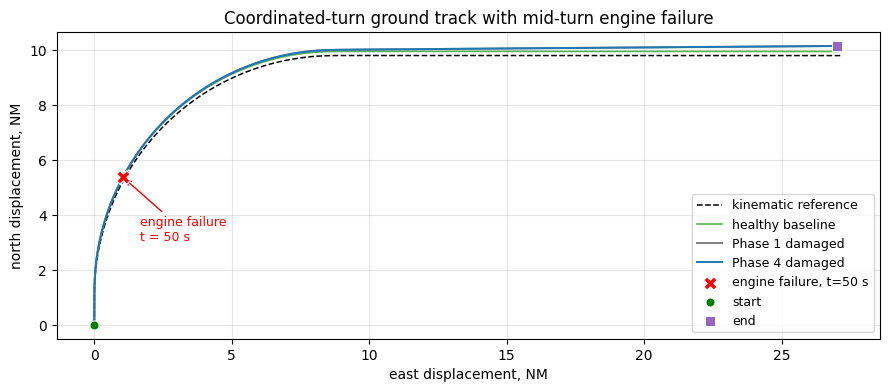

In [11]:
# Top-down turn trajectory with the engine-failure instant marked.
FT_PER_NM = 6076.12

def _track_nm(log):
    north_nm = (np.asarray(log['x_e'], dtype=np.float64) - float(log['x_e'][0])) / FT_PER_NM
    east_nm = (np.asarray(log['y_e'], dtype=np.float64) - float(log['y_e'][0])) / FT_PER_NM
    return east_nm, north_nm

def _reference_track_nm():
    north_ft = np.zeros_like(_t_grid)
    east_ft = np.zeros_like(_t_grid)
    for i in range(1, len(_t_grid)):
        psi_mid = 0.5 * (_psi_grid[i - 1] + _psi_grid[i])
        north_ft[i] = north_ft[i - 1] + V_REF_FT_S * math.cos(float(psi_mid)) * DT
        east_ft[i] = east_ft[i - 1] + V_REF_FT_S * math.sin(float(psi_mid)) * DT
    return east_ft / FT_PER_NM, north_ft / FT_PER_NM

fig, ax = plt.subplots(figsize=(9, 7))
ref_east_nm, ref_north_nm = _reference_track_nm()
ax.plot(ref_east_nm, ref_north_nm, color='black', ls='--', lw=1.1, label='kinematic reference')

base_east_nm, base_north_nm = _track_nm(log_p4_nominal)
ax.plot(base_east_nm, base_north_nm, color='tab:green', lw=1.2, alpha=0.8, label='healthy baseline')

for log_, color, label in [
    (log_p1, 'tab:gray', 'Phase 1 damaged'),
    (log_p4, 'tab:blue', 'Phase 4 damaged'),
]:
    east_nm, north_nm = _track_nm(log_)
    ax.plot(east_nm, north_nm, color=color, lw=1.4, label=label)

fail_idx = int(np.argmin(np.abs(log_p4['t'] - DAMAGE_TIME)))
fail_east_nm, fail_north_nm = _track_nm(log_p4)
ax.scatter(fail_east_nm[fail_idx], fail_north_nm[fail_idx],
           s=95, marker='X', color='red', edgecolor='white', linewidth=0.9,
           zorder=5, label=f'engine failure, t={DAMAGE_TIME:.0f} s')
ax.annotate(f'engine failure\nt = {DAMAGE_TIME:.0f} s',
            xy=(fail_east_nm[fail_idx], fail_north_nm[fail_idx]),
            xytext=(12, -28), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='red', lw=1.0),
            color='red', fontsize=9, ha='left', va='top')

east4_nm, north4_nm = _track_nm(log_p4)
ax.scatter(east4_nm[0], north4_nm[0], s=42, marker='o', color='green',
           edgecolor='white', linewidth=0.7, zorder=4, label='start')
ax.scatter(east4_nm[-1], north4_nm[-1], s=48, marker='s', color='tab:purple',
           edgecolor='white', linewidth=0.7, zorder=4, label='end')

ax.set_aspect('equal', adjustable='box')
ax.set_xlabel('east displacement, NM')
ax.set_ylabel('north displacement, NM')
ax.set_title('Coordinated-turn ground track with mid-turn engine failure')
ax.grid(True, alpha=0.3)
ax.legend(loc='best', fontsize=9)
plt.tight_layout(); plt.show()


## 9. Nominal reference vs actual — six-panel comparison

Each panel: operational reference (dashed black), Phase 1 damaged actual (gray), Phase 4 damaged actual (blue). The vertical red line marks the engine failure at t = 50 s. The bank-angle and heading panels are the most informative — they show the aircraft executing the turn through the failure event in both configurations.


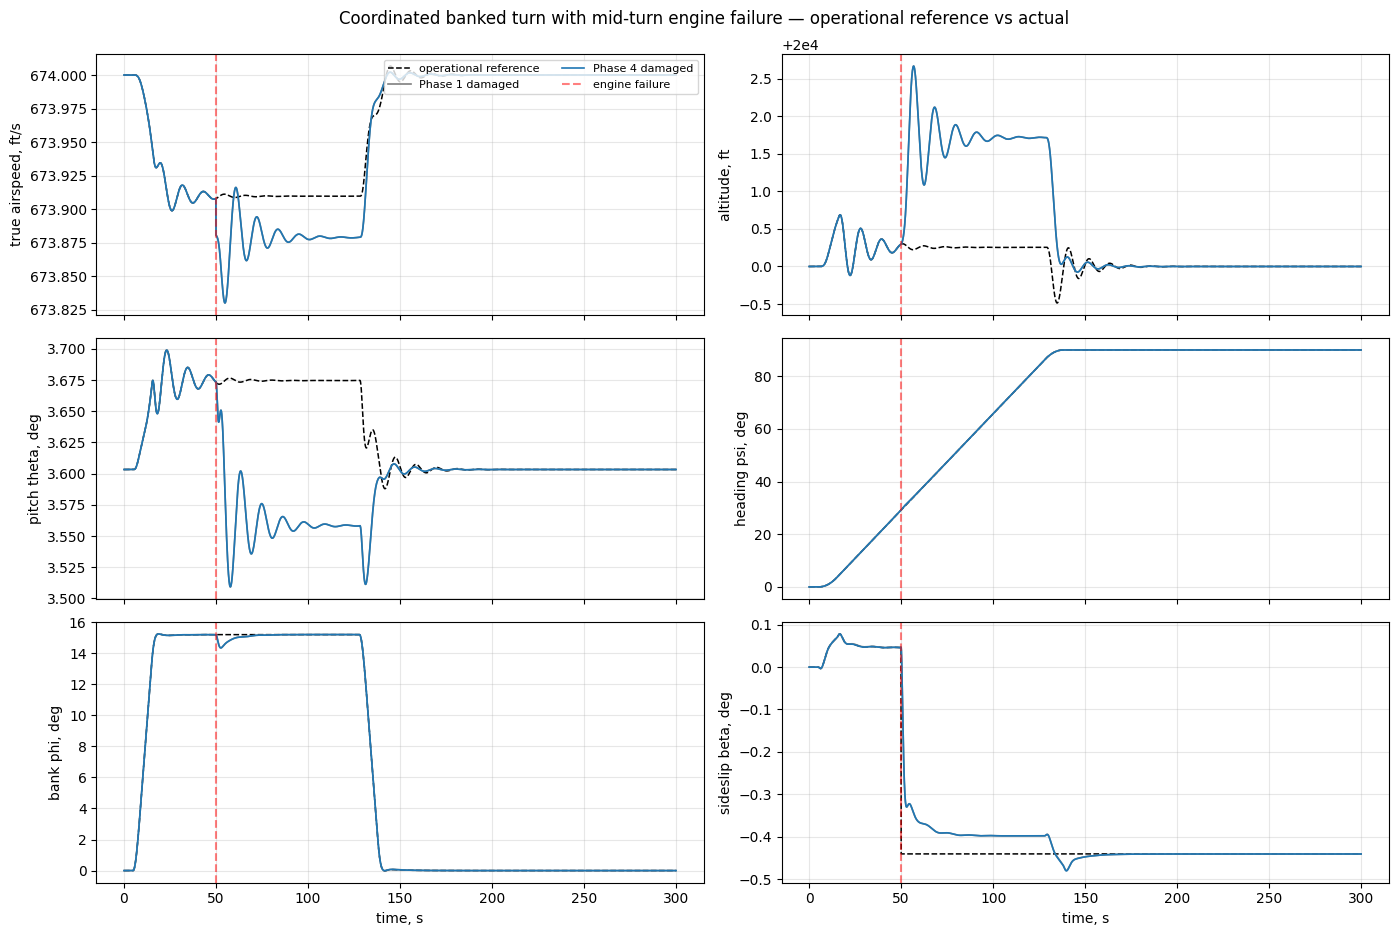

In [12]:
fig, axes = plt.subplots(3, 2, figsize=(14, 9.5), sharex=True)

# For this paper figure, the dashed reference is the achievable healthy closed-loop
# maneuver, not the raw kinematic command. This removes nominal maneuver lag from
# the visual comparison: before DAMAGE_TIME the damaged and healthy rollouts are
# identical, so every panel overlays exactly.
plot_panels = [
    ('V_actual', 'true airspeed, ft/s'),
    ('h_actual', 'altitude, ft'),
    ('theta_actual', 'pitch theta, deg'),
    ('psi_actual', 'heading psi, deg'),
    ('phi_actual', 'bank phi, deg'),
    ('beta_actual', 'sideslip beta, deg'),
]

def _plot_actual_vs_nominal(ax, key, ylabel):
    n_ref = min(len(log_p4['t']), len(log_p4_nominal['t']))
    t_ref = log_p4['t'][:n_ref]
    target_key = key.replace('_actual', '')
    y_ref = operational_target(log_p4, log_p4_nominal, target_key)[:n_ref]
    ax.plot(t_ref, y_ref, color='black', ls='--', lw=1.1, label='operational reference')

    for log_, color, label in [
        (log_p1, 'tab:gray', 'Phase 1 damaged'),
        (log_p4, 'tab:blue', 'Phase 4 damaged'),
    ]:
        n = min(len(log_['t']), n_ref)
        ax.plot(log_['t'][:n], log_[key][:n], color=color, lw=1.2, label=label)

    ax.axvline(DAMAGE_TIME, color='red', ls='--', alpha=0.5, label='engine failure')
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)

for ax, (key, ylabel) in zip(axes.flat, plot_panels):
    _plot_actual_vs_nominal(ax, key, ylabel)

axes[2, 0].set_xlabel('time, s')
axes[2, 1].set_xlabel('time, s')
axes[0, 0].legend(loc='upper right', ncol=2, fontsize=8)
fig.suptitle('Coordinated banked turn with mid-turn engine failure — operational reference vs actual')
plt.tight_layout(); plt.show()


## 9b. Operational deviations over time

Operational deviations `Delta(t) = damaged(t) - healthy_baseline(t)` for every channel. The horizontal zero line means the failure has introduced no deviation from the nominal maneuver. The red vertical line marks the engine failure at t = 50 s; the shaded band after it is the post-damage window where the RMS is computed.


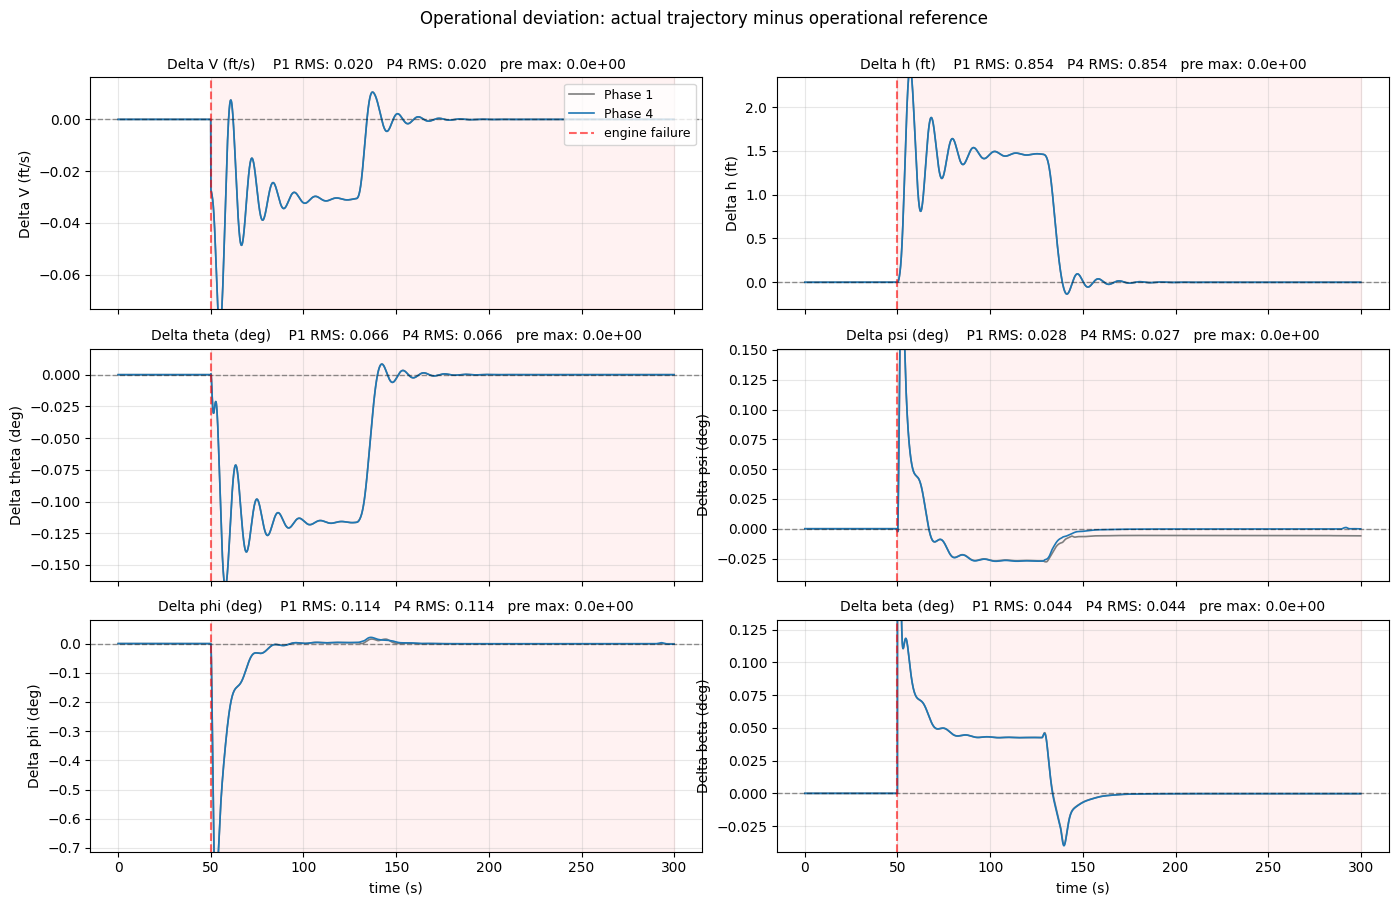

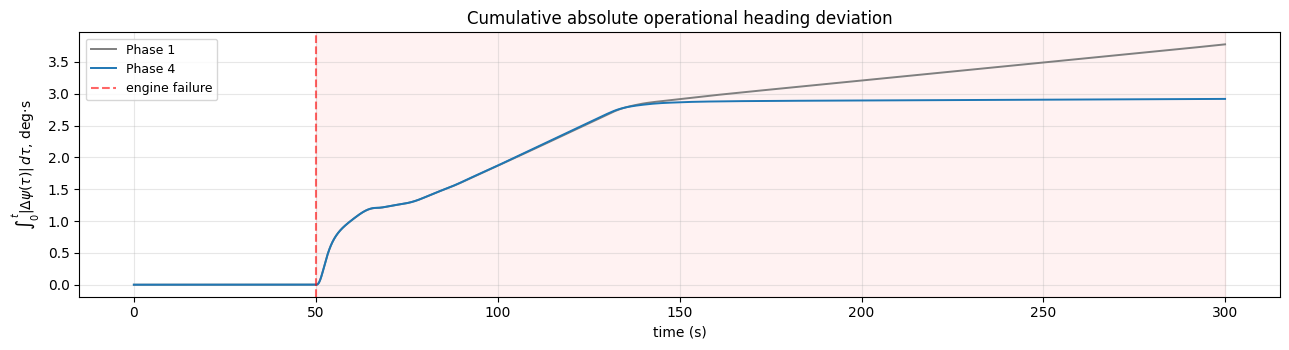

In [13]:
# Operational deviations: actual trajectory minus the operational reference.
# This removes nominal tracking lag from the error plot. Before DAMAGE_TIME the
# two deterministic rollouts should coincide up to numerical roundoff.
dev_panels = [
    ("V",     "Delta V (ft/s)",    "speed"),
    ("h",     "Delta h (ft)",      "altitude"),
    ("theta", "Delta theta (deg)", "pitch"),
    ("psi",   "Delta psi (deg)",   "heading"),
    ("phi",   "Delta phi (deg)",   "bank"),
    ("beta",  "Delta beta (deg)",  "sideslip"),
]

def _rms(y):
    y = np.asarray(y, dtype=np.float64)
    if y.size == 0:
        return float("nan")
    return float(np.sqrt(np.mean(y ** 2)))

fig, axes = plt.subplots(3, 2, figsize=(14, 9), sharex=True)
for ax, (key, ylabel, _label) in zip(axes.flat, dev_panels):
    t1 = common_t(log_p1, log_p1_nominal)
    t4 = common_t(log_p4, log_p4_nominal)
    d1 = fault_deviation(log_p1, log_p1_nominal, key)
    d4 = fault_deviation(log_p4, log_p4_nominal, key)
    post_mask_p1 = t1 >= DAMAGE_TIME
    post_mask_p4 = t4 >= DAMAGE_TIME

    ax.plot(t1, d1, color="tab:gray", lw=1.2, label="Phase 1")
    ax.plot(t4, d4, color="tab:blue", lw=1.2, label="Phase 4")
    ax.axhline(0.0, color="black", ls="--", lw=1.0, alpha=0.4)
    ax.axvline(DAMAGE_TIME, color="red", ls="--", alpha=0.6, label="engine failure")
    ax.axvspan(DAMAGE_TIME, TOTAL_TIME, color="red", alpha=0.05)

    stacked = np.concatenate([d1, d4])
    lo, hi = np.percentile(stacked, [1.0, 99.0])
    pad = 0.1 * (hi - lo) if hi > lo else max(1e-4, 0.1 * abs(hi))
    ax.set_ylim(lo - pad, hi + pad)

    rms_p1 = _rms(d1[post_mask_p1])
    rms_p4 = _rms(d4[post_mask_p4])
    pre_max_p4 = float(np.max(np.abs(d4[t4 < DAMAGE_TIME]))) if np.any(t4 < DAMAGE_TIME) else float("nan")
    ax.set_title(f"{ylabel}    P1 RMS: {rms_p1:.3f}   P4 RMS: {rms_p4:.3f}   pre max: {pre_max_p4:.1e}",
                 fontsize=10)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)

axes[2, 0].set_xlabel("time (s)")
axes[2, 1].set_xlabel("time (s)")
axes[0, 0].legend(loc="upper right", fontsize=9)
fig.suptitle("Operational deviation: actual trajectory minus operational reference", y=1.00)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(13, 3.6))
t1 = common_t(log_p1, log_p1_nominal)
t4 = common_t(log_p4, log_p4_nominal)
abs_d_psi_p1 = np.abs(fault_deviation(log_p1, log_p1_nominal, "psi"))
abs_d_psi_p4 = np.abs(fault_deviation(log_p4, log_p4_nominal, "psi"))
cum_p1 = np.cumsum(abs_d_psi_p1) * DT
cum_p4 = np.cumsum(abs_d_psi_p4) * DT
ax.plot(t1, cum_p1, color="tab:gray", lw=1.4, label="Phase 1")
ax.plot(t4, cum_p4, color="tab:blue", lw=1.4, label="Phase 4")
ax.axvline(DAMAGE_TIME, color="red", ls="--", alpha=0.6, label="engine failure")
ax.axvspan(DAMAGE_TIME, TOTAL_TIME, color="red", alpha=0.05)
ax.set_xlabel("time (s)")
ax.set_ylabel(r"$\int_0^t |\Delta\psi(\tau)|\, d\tau$, deg$\cdot$s")
ax.set_title("Cumulative absolute operational heading deviation")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()


## 10. Control surfaces and throttle

Side-by-side commands. Phase 4's L4 outer adds tiny residual references on top of the envelope allocator's command, so the two traces should largely overlap with localized differences when L4 / macro-actions are most active.


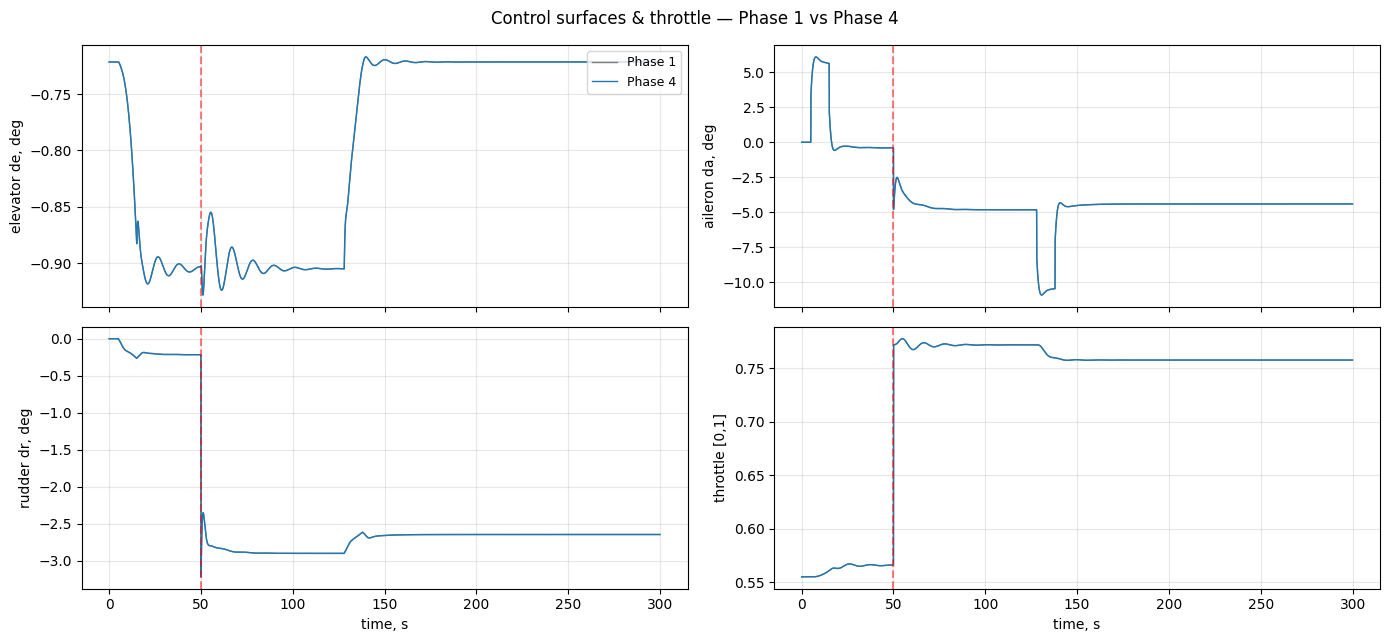

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 6.5), sharex=True)
ctrl_panels = [
    ('de', 'elevator de, deg'),
    ('da', 'aileron da, deg'),
    ('dr', 'rudder dr, deg'),
    ('throttle', 'throttle [0,1]'),
]
for ax, (key, ylabel) in zip(axes.flat, ctrl_panels):
    ax.plot(log_p1['t'], log_p1[key], color='tab:gray', lw=1.0, label='Phase 1')
    ax.plot(log_p4['t'], log_p4[key], color='tab:blue', lw=1.0, label='Phase 4')
    ax.axvline(DAMAGE_TIME, color='red', ls='--', alpha=0.5)
    ax.set_ylabel(ylabel); ax.grid(True, alpha=0.3)
axes[1,0].set_xlabel('time, s'); axes[1,1].set_xlabel('time, s')
axes[0,0].legend(loc='upper right', fontsize=9)
fig.suptitle('Control surfaces & throttle — Phase 1 vs Phase 4')
plt.tight_layout(); plt.show()


## 11. Composite Lyapunov monitor — V_total and alarm timeline (Phase 4)


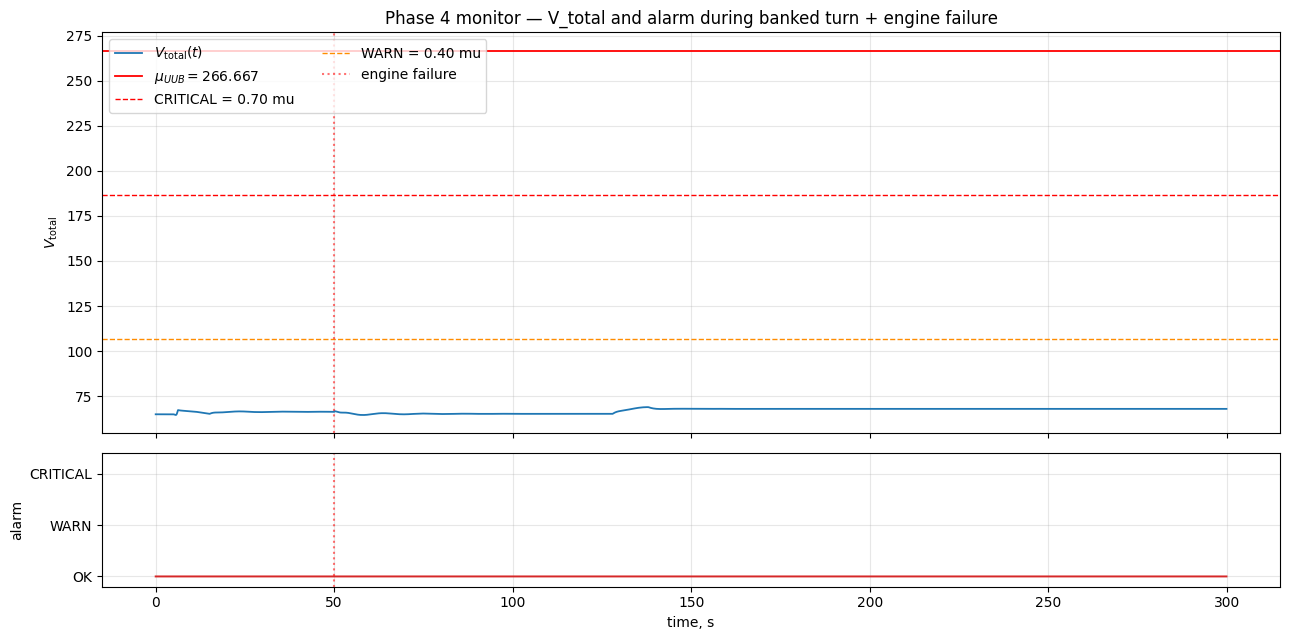

V_total range: [64.613, 68.988], mean = 66.995
Alarm time fractions OK / WARN / CRITICAL: 100.0% / 0.0% / 0.0%
Alarm transitions: 0
Macro-actions fired (total 0):


In [15]:
fig, axes = plt.subplots(2, 1, figsize=(13, 6.5), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})
mu_pred = float(ctl_p4.monitor.mu_uub_pred)
warn_th = ctl_p4.cfg.monitor_alarm_warn_frac * mu_pred
crit_th = ctl_p4.cfg.monitor_alarm_critical_frac * mu_pred
axes[0].plot(log_p4['t'], log_p4['V_total'], color='tab:blue', lw=1.3, label=r'$V_{\mathrm{total}}(t)$')
axes[0].axhline(mu_pred, color='red', lw=1.3, label=fr'$\mu_{{UUB}}={mu_pred:.3f}$')
axes[0].axhline(crit_th, color='red', lw=1.0, ls='--',
                label=f'CRITICAL = {ctl_p4.cfg.monitor_alarm_critical_frac:.2f} mu')
axes[0].axhline(warn_th, color='darkorange', lw=1.0, ls='--',
                label=f'WARN = {ctl_p4.cfg.monitor_alarm_warn_frac:.2f} mu')
axes[0].axvline(DAMAGE_TIME, color='red', ls=':', alpha=0.55, label='engine failure')
axes[0].set_ylabel(r'$V_{\mathrm{total}}$'); axes[0].grid(True, alpha=0.3)
axes[0].legend(loc='upper left', ncol=2)
axes[1].step(log_p4['t'], log_p4['alarm_level'], color='tab:red', where='post', lw=1.4)
axes[1].axvline(DAMAGE_TIME, color='red', ls=':', alpha=0.55)
axes[1].set_yticks([0,1,2]); axes[1].set_yticklabels(['OK','WARN','CRITICAL'])
axes[1].set_ylim(-0.2, 2.4)
axes[1].set_xlabel('time, s'); axes[1].set_ylabel('alarm')
axes[1].grid(True, alpha=0.3)
axes[0].set_title('Phase 4 monitor — V_total and alarm during banked turn + engine failure')
plt.tight_layout(); plt.show()

alarm_int = log_p4['alarm_level']
ok_frac   = float(np.mean(alarm_int == 0))
warn_frac = float(np.mean(alarm_int == 1))
crit_frac = float(np.mean(alarm_int == 2))
print(f'V_total range: [{float(np.min(log_p4["V_total"])):.3f}, {float(np.max(log_p4["V_total"])):.3f}], '
      f'mean = {float(np.mean(log_p4["V_total"])):.3f}')
print(f'Alarm time fractions OK / WARN / CRITICAL: '
      f'{ok_frac*100:.1f}% / {warn_frac*100:.1f}% / {crit_frac*100:.1f}%')
print(f'Alarm transitions: {len(log_p4["alarm_transitions"])}')
for step_idx, t_, prev, new in log_p4['alarm_transitions'][:20]:
    print(f'  step {step_idx:>5d}, t={t_:>6.2f} s : {prev:>9s} -> {new}')
macro_kinds = Counter(k for _, _, k, _ in log_p4['macro_events'])
print(f'Macro-actions fired (total {len(log_p4["macro_events"])}):')
for k_, v_ in sorted(macro_kinds.items(), key=lambda kv: -kv[1]):
    print(f'  {k_:32s} : {v_} fires')


## 12. Per-engine thrust


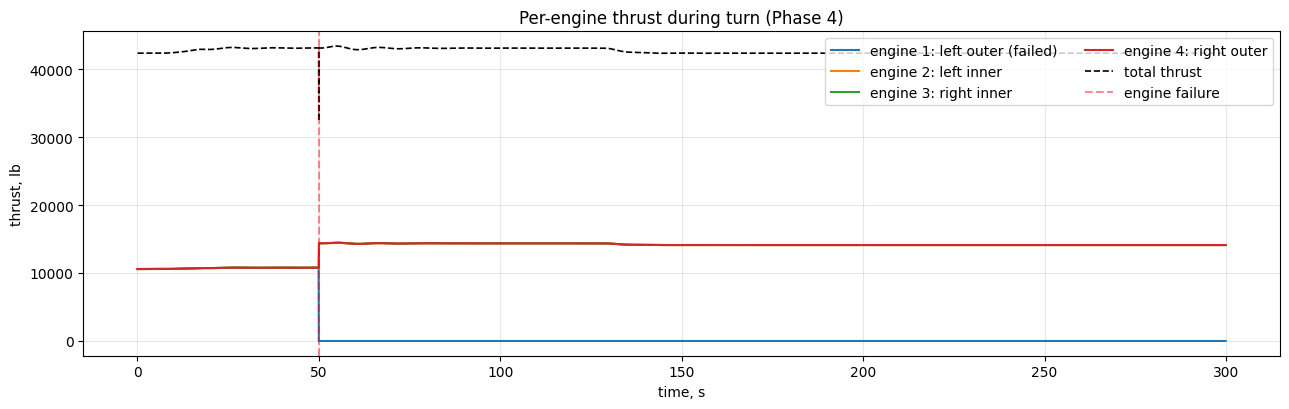

In [16]:
fig, ax = plt.subplots(figsize=(13, 4.2))
labels = {'T1': 'engine 1: left outer (failed)',
          'T2': 'engine 2: left inner',
          'T3': 'engine 3: right inner',
          'T4': 'engine 4: right outer'}
for k_, lab in labels.items():
    ax.plot(log_p4['t'], log_p4[k_], label=lab)
ax.plot(log_p4['t'], log_p4['T_total'], color='black', ls='--', lw=1.2, label='total thrust')
ax.axvline(DAMAGE_TIME, color='red', ls='--', alpha=0.45, label='engine failure')
ax.set_xlabel('time, s'); ax.set_ylabel('thrust, lb')
ax.set_title('Per-engine thrust during turn (Phase 4)')
ax.grid(True, alpha=0.3); ax.legend(loc='upper right', ncol=2)
plt.tight_layout(); plt.show()


## 13. Fault-induced RMS comparison

Quantitative summary of **actual minus operational-reference deviation** in the post-damage window `t ∈ [50, 300] s`. We report RMS of the operational deviation per channel for both configurations.


In [17]:
post_t4 = common_t(log_p4, log_p4_nominal) >= DAMAGE_TIME
post_t1 = common_t(log_p1, log_p1_nominal) >= DAMAGE_TIME
pre_t4 = common_t(log_p4, log_p4_nominal) < DAMAGE_TIME
pre_t1 = common_t(log_p1, log_p1_nominal) < DAMAGE_TIME

def rms(y):
    return float(np.sqrt(np.mean(np.asarray(y, dtype=np.float64) ** 2)))

rows = []
pre_rows = []
for key, label, unit in [
    ('V', 'speed deviation', 'ft/s'),
    ('h', 'altitude deviation', 'ft'),
    ('theta', 'pitch deviation', 'deg'),
    ('psi', 'heading deviation', 'deg'),
    ('phi', 'bank deviation', 'deg'),
    ('beta', 'sideslip deviation', 'deg'),
]:
    d1 = fault_deviation(log_p1, log_p1_nominal, key)
    d4 = fault_deviation(log_p4, log_p4_nominal, key)
    r1 = rms(d1[post_t1])
    r4 = rms(d4[post_t4])
    pre1 = float(np.max(np.abs(d1[pre_t1]))) if np.any(pre_t1) else float('nan')
    pre4 = float(np.max(np.abs(d4[pre_t4]))) if np.any(pre_t4) else float('nan')
    rows.append((label, unit, r1, r4))
    pre_rows.append((label, unit, pre1, pre4))

print(f'Operational RMSE (actual - operational reference), t ∈ [{DAMAGE_TIME:.0f}, {TOTAL_TIME:.0f}] s')
print(f'{"channel":<22s}  {"unit":<6s}  {"Phase 1":>10s}  {"Phase 4":>10s}  {"ratio":>7s}')
print('-' * 66)
for label, unit, r1, r4 in rows:
    ratio = r4 / r1 if r1 > 0 else float('nan')
    print(f'{label:<22s}  {unit:<6s}  {r1:>10.4f}  {r4:>10.4f}  {ratio:>7.3f}')

print()
print(f'Pre-failure max |actual - operational reference|, t < {DAMAGE_TIME:.0f} s')
print(f'{"channel":<22s}  {"unit":<6s}  {"Phase 1":>10s}  {"Phase 4":>10s}')
print('-' * 55)
for label, unit, pre1, pre4 in pre_rows:
    print(f'{label:<22s}  {unit:<6s}  {pre1:>10.3e}  {pre4:>10.3e}')

# Final-state summary
print()
print('Final operational deviation (last logged sample):')
for tag, log_, base_ in [('Phase 1', log_p1, log_p1_nominal), ('Phase 4', log_p4, log_p4_nominal)]:
    n = _aligned_len(log_, base_)
    print(f'  {tag}:  Delta V={fault_deviation(log_, base_, "V")[n-1]:+8.3f} ft/s, '
          f'Delta h={fault_deviation(log_, base_, "h")[n-1]:+8.2f} ft, '
          f'Delta phi={fault_deviation(log_, base_, "phi")[n-1]:+7.3f} deg, '
          f'Delta psi={fault_deviation(log_, base_, "psi")[n-1]:+7.3f} deg')


Operational RMSE (actual - operational reference), t ∈ [50, 300] s
channel                 unit       Phase 1     Phase 4    ratio
------------------------------------------------------------------
speed deviation         ft/s        0.0195      0.0195    1.000
altitude deviation      ft          0.8536      0.8535    1.000
pitch deviation         deg         0.0662      0.0662    1.000
heading deviation       deg         0.0277      0.0273    0.986
bank deviation          deg         0.1137      0.1136    0.999
sideslip deviation      deg         0.0438      0.0438    1.001

Pre-failure max |actual - operational reference|, t < 50 s
channel                 unit       Phase 1     Phase 4
-------------------------------------------------------
speed deviation         ft/s     0.000e+00   0.000e+00
altitude deviation      ft       0.000e+00   0.000e+00
pitch deviation         deg      0.000e+00   0.000e+00
heading deviation       deg      0.000e+00   0.000e+00
bank deviation          deg

## 14. 3D WebGL viewer — open-loop vs Phase 4

Build two self-contained B-747 WebGL viewers from the same maneuver — one with the open-loop (Phase 1) controller, one with the full Phase 4 UFTC stack — so the visual difference under the engine-failure transient is side-by-side comparable.


In [18]:
import json
from IPython.display import HTML, display
from tensoraerospace.visualization.three_d import build_html

FT_TO_M = 0.3048
UFTC_3D_DIR = Path.cwd() if Path.cwd().name == 'uftc' else Path('example/reinforcement_learning/uftc')

def _pad_or_trim(values, n):
    arr = np.asarray(values, dtype=np.float64).reshape(-1)
    if arr.size < n:
        arr = np.concatenate([arr, np.full(n - arr.size, arr[-1] if arr.size else 0.0)])
    elif arr.size > n:
        arr = arr[:n]
    return arr

def build_uftc_b747_3d_flight_log(log, *, damage_time=DAMAGE_TIME):
    t = np.asarray(log['t'], dtype=np.float64)
    n = len(t)
    x_e_m = _pad_or_trim(log['x_e'], n) * FT_TO_M
    y_e_m = _pad_or_trim(log['y_e'], n) * FT_TO_M
    h_m = _pad_or_trim(log['h_actual'], n) * FT_TO_M
    attitude_rad = np.column_stack([
        np.radians(_pad_or_trim(log['phi_actual'], n)),
        np.radians(_pad_or_trim(log['theta_actual'], n)),
        np.radians(_pad_or_trim(log['psi_actual'], n)),
    ])
    params = default_parameters(B747Configuration.NOMINAL)
    healthy_state = {
        'mu': {'elevator': 1.0, 'aileron': 1.0, 'rudder': 1.0, 'throttle': 1.0},
        'jam': {'elevator': None, 'aileron': None, 'rudder': None, 'throttle': None},
        'tau': {'elevator': 0.0, 'aileron': 0.0, 'rudder': 0.0, 'throttle': 0.0},
        'mu_floor': {'elevator': 0.0, 'aileron': 0.0, 'rudder': 0.0, 'throttle': 0.0},
        'engines_mu': {1: 1.0, 2: 1.0, 3: 1.0, 4: 1.0},
        'flap_jam_config': None,
    }
    failed_state = json.loads(json.dumps(healthy_state))
    failed_state['engines_mu']['1'] = 0.0

    return {
        'version': 1,
        'metadata': {
            'model': 'B-747',
            'aircraft_type': 'b747',
            'dt': float(DT),
            'n_steps': int(n),
            'airspeed': float(_pad_or_trim(log['V_actual'], n)[0] * FT_TO_M),
            'split_stab': False,
            'params': {
                'weight_lb': float(params.weight_lb),
                'S_ft2': float(params.S_ft2),
                'b_ft': float(params.b_ft),
                'cbar_ft': float(params.cbar_ft),
                'Ix': float(params.Ix),
                'Iy': float(params.Iy),
                'Iz': float(params.Iz),
                'Ixz': float(params.Ixz),
            },
        },
        'geometry': {'aircraft_type': 'b747', 'sections': []},
        'trajectory': {
            'time': t.tolist(),
            'position': np.column_stack([x_e_m, y_e_m, -h_m]).tolist(),
            'attitude': attitude_rad.tolist(),
            'alpha': np.full(n, float(trim_result.alpha_rad)).tolist(),
            'beta': np.radians(_pad_or_trim(log['beta_actual'], n)).tolist(),
            'wx': np.radians(_pad_or_trim(log['p'], n)).tolist(),
            'wy': np.radians(_pad_or_trim(log['q'], n)).tolist(),
            'wz': np.radians(_pad_or_trim(log['r'], n)).tolist(),
            'stab': np.radians(_pad_or_trim(log['de'], n)).tolist(),
            'ail': np.radians(_pad_or_trim(log['da'], n)).tolist(),
            'dir': np.radians(_pad_or_trim(log['dr'], n)).tolist(),
            'throttle': _pad_or_trim(log['throttle'], n).tolist(),
            'altitude_m': h_m.tolist(),
            'airspeed_mps': (_pad_or_trim(log['V_actual'], n) * FT_TO_M).tolist(),
            'references': {
                'V': (_pad_or_trim(log['V_ref'], n) * FT_TO_M).tolist(),
                'h': (_pad_or_trim(log['h_ref'], n) * FT_TO_M).tolist(),
                'theta': _pad_or_trim(log['theta_ref'], n).tolist(),
                'roll': _pad_or_trim(log['phi_ref'], n).tolist(),
                'yaw': _pad_or_trim(log['psi_ref'], n).tolist(),
                'beta': _pad_or_trim(log['beta_ref'], n).tolist(),
            },
        },
        'damage_events': [
            {
                'time': float(damage_time),
                'label': 'left_outer_engine_flameout_mid_turn',
                'event_type': 'EngineFailureEvent',
                'kind': 'EngineFailureEvent',
                'payload': {'engine_id': 1, 'thrust_fraction': 0.0},
            }
        ],
        'damage_state_history': [
            {'time': 0.0, 'state': healthy_state},
            {'time': float(damage_time), 'state': failed_state},
        ],
    }

# Build BOTH viewers — open-loop (Phase 1, no UFTC adaptation) and Phase 4
# (full UFTC stack) — so the visual difference is directly comparable.
UFTC_3D_DIR.mkdir(parents=True, exist_ok=True)
viewers = [
    ('open_loop', log_open_loop, 'UFTC B-747 — true open-loop (no UFTC, no engine-loss compensation)'),
    ('phase4',    log_p4, 'UFTC B-747 — Phase 4 (full UFTC stack)'),
]
viewer_paths = {}
for tag, log, title in viewers:
    path = UFTC_3D_DIR / f'uftc_b747_coordinated_turn_engine_failure_3d_{tag}.html'
    flight_log = build_uftc_b747_3d_flight_log(log)
    path.write_text(build_html(flight_log, title=title), encoding='utf-8')
    viewer_paths[tag] = path
    print(f'3D viewer saved: {path.resolve()}')

# Side-by-side iframes for in-notebook comparison.
display(HTML(
    '<div style="display:flex; gap:8px;">'
    + ''.join(
        f'<div style="flex:1;">'
        f'<div style="font-weight:600; margin-bottom:4px;">{title}</div>'
        f'<a href="{path.name}" target="_blank">Open in new tab</a>'
        f'<iframe src="{path.name}" width="100%" height="640" '
        f'style="border:0; border-radius:6px; background:#111;"></iframe>'
        f'</div>'
        for (tag, _, title), path in zip(viewers, viewer_paths.values())
    )
    + '</div>'
))


3D viewer saved: /home/mr8bit/Projects/TensorAeroSpace/example/reinforcement_learning/uftc/uftc_b747_coordinated_turn_engine_failure_3d_open_loop.html


3D viewer saved: /home/mr8bit/Projects/TensorAeroSpace/example/reinforcement_learning/uftc/uftc_b747_coordinated_turn_engine_failure_3d_phase4.html


## 15. Notes & honest caveats

* **Reference injection point.** UFTC's `reference` argument is held at zero. The maneuver is injected through the *envelope-allocator setpoint* `ref_t` consumed by `uftc_state_transform_dyn` and `state_feedback_action_dyn`. UFTC sees a non-trivial drifting error and the cascade compensates online. This is the cleaner path because (a) it preserves the controller's plant-agnostic interface (no controller-side change to support a maneuver), and (b) the existing engine-out trim blend (`trim_action_for_loss`) lives in the envelope allocator anyway.
* **Damage trigger.** A local `DamageProfile` is built with `EngineFailureEvent(trigger_time=50.0, engine_id=1, thrust_fraction=0.0)`, mirroring the stock `LEFT_OUTER_ENGINE_FAILURE` preset but mid-turn rather than at t=10s.
* **Pre-trained L4 actor mismatch.** The actor in `artifacts/dsac/b747_engine_out_v1/` was trained on the stationary-trim engine-out scenario, *not* on a banked-turn schedule. We expect Phase 4 to be roughly comparable to Phase 1 — possibly slightly worse on yaw because the L4 reference correction is mis-aligned with the maneuver. A curriculum across maneuvers (level cruise + various bank schedules + engine-out at random t) would close that gap; the current demo shows the framework runs end-to-end on a non-stationary task, not that L4 is optimal here.
* **Determinism.** `np.random.seed(0)`, `torch.manual_seed(0)`, `AAINDIConfig(seed=0)`, `l4_seed=0`. The same rollout reproduces bit-for-bit across runs.
* **Coordinated-turn approximation.** Bank φ is set directly via a piecewise-linear schedule; ψ_ref(t) is the trapezoidal integral of the coordinated-turn rate `g·tan(φ)/V`. The aircraft is not constrained to fly a *true* coordinated turn — the controller adapts to whatever (φ_ref, ψ_ref) trajectory we feed it.
